# Taller 4: Detección de contornos

## Cargue y visualice la imagen rondelle.png. Aplique el operador de Sobel y describa el resultado (puede efectuar una calibración del histograma de la imagen obtenida para visualizar mejor el resultado).

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import sobel_h, sobel_v, sobel, prewitt_h, prewitt_v, prewitt
from skimage import exposure
from skimage.feature import canny


In [2]:
PATH = "./imagenes/"

In [10]:
imagen = cv2.imread(PATH + "RONDELLE.png", cv2.IMREAD_GRAYSCALE)
imagen_calibrada = exposure.rescale_intensity(imagen, in_range=(imagen.min(), imagen.max()),\
                                               out_range=(0, 255)).astype(np.uint8)
imagen_sobel = sobel(imagen)
imagen_calibrada_sobel = sobel(imagen_calibrada)

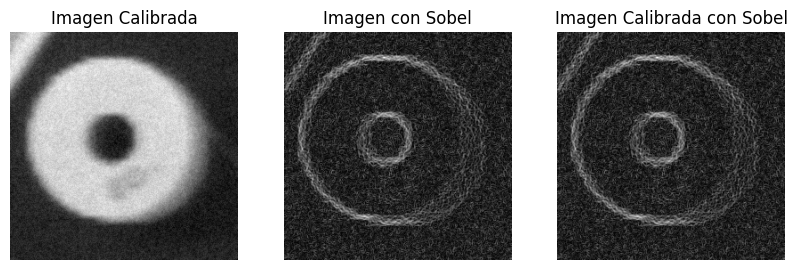

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(imagen_calibrada, cmap='gray')
ax[0].set_title("Imagen Calibrada")
ax[0].axis('off')
ax[1].imshow(imagen_sobel, cmap='gray')
ax[1].set_title("Imagen con Sobel")
ax[1].axis('off')
ax[2].imshow(imagen_calibrada_sobel, cmap='gray')
ax[2].set_title("Imagen Calibrada con Sobel")
ax[2].axis('off')
plt.show()

Podemos obeservar que la imagen tiene muchos artefactos debido al ruido que tiene. A pesar de la calibración, el filtro sobel no logra definir los contornos claramente.

## Ahora aplique sobre la imagen original el operador de Canny, con los siguientes valores de parámetros y visualice la imagen resultado y descríbala:

a. Desviación estándar = 10- Esto indica que se va a filtrar considerablemente la imagen original.

b. Umbral inferior (low_threshold) = 0

c. Umbral superior (high_threshold) = 1. Este umbral permite eliminar la mayoría de falsas detecciones de pequeña amplitud del gradiente.

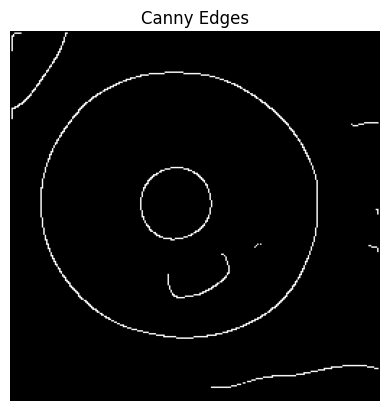

In [16]:

from skimage.feature import canny

edges2 = canny(imagen, sigma=10, low_threshold=0, high_threshold=1)

plt.imshow(edges2, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')
plt.show()

## Disminuya la desviación a estándar a 5 (en X y en Y ), visualice la imagen resultado y explique lo que sucede.

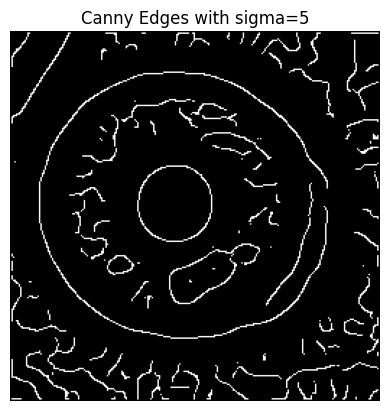

In [17]:
edges_sigma_5 = canny(imagen, sigma=5, low_threshold=0, high_threshold=1)

plt.imshow(edges_sigma_5, cmap='gray')
plt.title('Canny Edges with sigma=5')
plt.axis('off')
plt.show()

Al disminuir la desviación estándar de 10 a 5, el filtro gaussiano suaviza menos la imagen y, como resultado, el operador de Canny detecta más bordes, incluyendo detalles y ruido que antes eran eliminados.

## Aumente el umbral superior a 5 con los valores de desviación estándar del punto 3 y 4. visualice y compare los resultados con las imágenes obtenidas en el punto anterior.

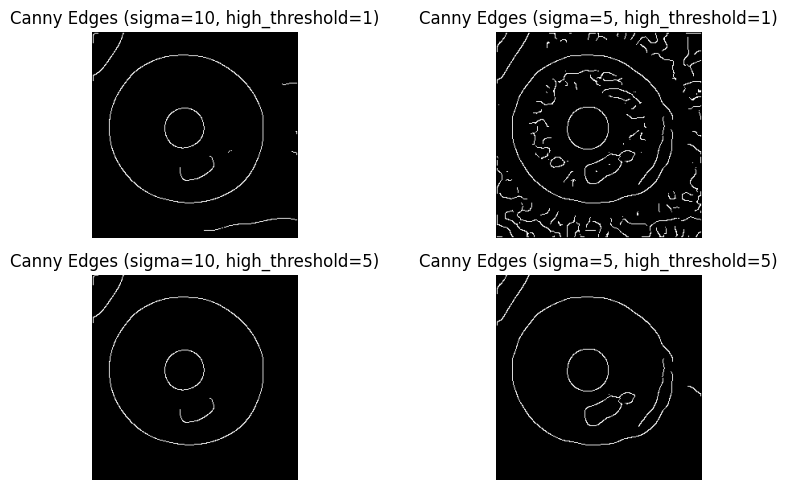

In [18]:
edges_sigma10_high_thresh_5 = canny(imagen, sigma=10, low_threshold=0, high_threshold=5)
edges_sigma5_high_thresh_5 = canny(imagen, sigma=5, low_threshold=0, high_threshold=5)
fig, ax = plt.subplots(2, 2, figsize=(10, 5))
ax[0, 0].imshow(edges2, cmap='gray')
ax[0, 0].set_title('Canny Edges (sigma=10, high_threshold=1)')
ax[0, 0].axis('off')
ax[0, 1].imshow(edges_sigma_5, cmap='gray')
ax[0, 1].set_title('Canny Edges (sigma=5, high_threshold=1)')
ax[0, 1].axis('off')
ax[1, 0].imshow(edges_sigma10_high_thresh_5, cmap='gray')
ax[1, 0].set_title('Canny Edges (sigma=10, high_threshold=5)')
ax[1, 0].axis('off')
ax[1, 1].imshow(edges_sigma5_high_thresh_5, cmap='gray')
ax[1, 1].set_title('Canny Edges (sigma=5, high_threshold=5)')
ax[1, 1].axis('off')
plt.tight_layout()
plt.show()

Al aumentar el umbral superior a 5, tanto con sigma=10 como con sigma=5, se observa que la cantidad de bordes detectados disminuye notablemente en comparación con los resultados anteriores (donde el umbral superior era 1). Ahora, solo se conservan los contornos más fuertes y definidos, mientras que los bordes débiles y el ruido desaparecen casi por completo.

En resumen, un umbral superior más alto hace que el operador de Canny sea más selectivo, mostrando únicamente los bordes más marcados y eliminando detalles y bordes tenues, independientemente del valor de sigma utilizado.